In [1]:
%cd ../..

/scratch/big/home/daawic/BSc-Thesis


In [2]:
import os
import ale_py
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from project.agents import DQNAgent
from project.environments.loops import TestingLoop

In [3]:
BREAKOUT = os.path.join("..", "checkpoints", "dqn", "Breakout.pt")
SPACE_INVADERS = os.path.join("..", "checkpoints", "dqn", "SpaceInvaders.pt")

In [4]:
def plot_images(images):
    fig, axes = plt.subplots(1, 2)
    fig.set_size_inches(8, 4)

    for i in range(2):
            axes[i].imshow(images[i], cmap='grey')
            axes[i].axis("off")

    fig.tight_layout()

In [5]:
def wrap(env):
    env = gym.wrappers.AtariPreprocessing(env)
    env = gym.wrappers.FrameStackObservation(env, stack_size=4)
    return env

In [6]:
env_b = gym.make("ALE/Breakout-v5", frameskip=1, repeat_action_probability=0.)
env_si = gym.make("ALE/SpaceInvaders-v5", frameskip=1, repeat_action_probability=0.)

env_b_wrapped = wrap(env_b)
env_si_wrapped = wrap(env_si)

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


In [7]:
state_b, _ = env_b.reset()
state_si, _ = env_si.reset()

state_b_wrapped, _ = env_b_wrapped.reset()
state_si_wrapped, _ = env_si_wrapped.reset()

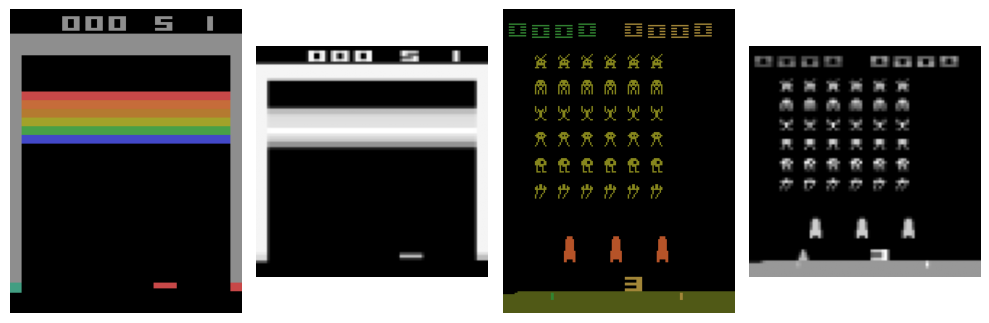

In [10]:
fig, axes = plt.subplots(1, 4)
fig.set_size_inches(10, 5)

axes[0].imshow(state_b)
axes[0].axis("off")

axes[2].imshow(state_si)
axes[2].axis("off")

axes[1].imshow(state_b_wrapped.mean(axis=0), cmap="grey")
axes[1].axis("off")

axes[3].imshow(state_si_wrapped.mean(axis=0), cmap="grey")
axes[3].axis("off")

fig.tight_layout()

plt.savefig("states.svg")
plt.show()